### В этом блокноте проводится EDA для корпуса данных AgeVoxceleb для построения основных зависимостей и распределений

Импорт библиотек

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import librosa
import os

Загрузка датасета

In [ ]:
metadata_path = "./agevoxceleb/utt2age.test"

In [5]:
df_age = pd.read_csv(metadata_path, sep='\s+', header=None, names=['utterance_id', 'age'])
print(f"Загружено {len(df_age)} записей")

Загружено 16050 записей


In [6]:
df_age.head()

,utterance_id,age
0,id00042/34f5sBShxSo/00001,70
1,id00042/34f5sBShxSo/00002,70
2,id00042/34f5sBShxSo/00003,70
3,id00042/34f5sBShxSo/00004,70
4,id00042/34f5sBShxSo/00005,70


Распределение по возрасту

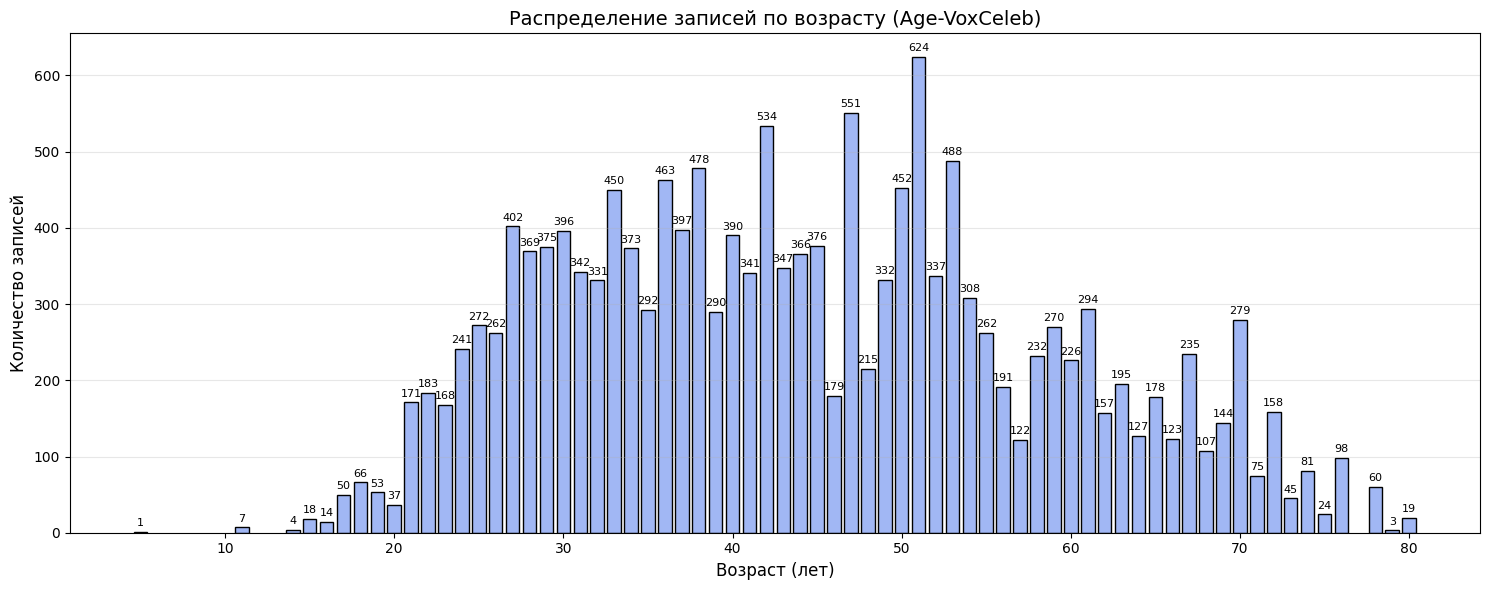


Статистика Age-VoxCeleb (test):

Всего записей: 16050
Возрастной диапазон: 5-80 лет
Средний возраст: 44.3 лет
Стандартное отклонение: 14.0 лет


In [13]:
# Строим график распределения возрастов
plt.figure(figsize=(15, 6))

age_counts = df_age['age'].value_counts().sort_index()
plt.bar(age_counts.index, age_counts.values, color='#A1B7F4', edgecolor='black')
plt.xlabel('Возраст (лет)', fontsize=12)
plt.ylabel('Количество записей', fontsize=12)
plt.title('Распределение записей по возрасту (Age-VoxCeleb)', fontsize=14)
plt.grid(True, alpha=0.3, axis='y')

# Добавляем подписи значений
for age, count in age_counts.items():
    plt.text(age, count + 5, str(count), ha='center', va='bottom', fontsize=8)


plt.tight_layout()
plt.show()

# Статистика
print(f"\nСтатистика Age-VoxCeleb (test):\n")
print(f"Всего записей: {len(df_age)}")
print(f"Возрастной диапазон: {df_age['age'].min()}-{df_age['age'].max()} лет")
print(f"Средний возраст: {df_age['age'].mean():.1f} лет")
print(f"Стандартное отклонение: {df_age['age'].std():.1f} лет")

Распределение длительностей

In [ ]:
voxceleb2_path = "./databases/voxceleb2/"

Поиск WAV файлов...
Найдено 1000 WAV файлов...
Найдено 2000 WAV файлов...
Найдено 3000 WAV файлов...
Найдено 4000 WAV файлов...
Найдено 5000 WAV файлов...
Найдено 6000 WAV файлов...
Найдено 7000 WAV файлов...
Найдено 8000 WAV файлов...
Найдено 9000 WAV файлов...
Найдено 10000 WAV файлов...
Найдено 11000 WAV файлов...
Найдено 12000 WAV файлов...
Найдено 13000 WAV файлов...
Найдено 14000 WAV файлов...
Найдено 15000 WAV файлов...
Найдено 16000 WAV файлов...


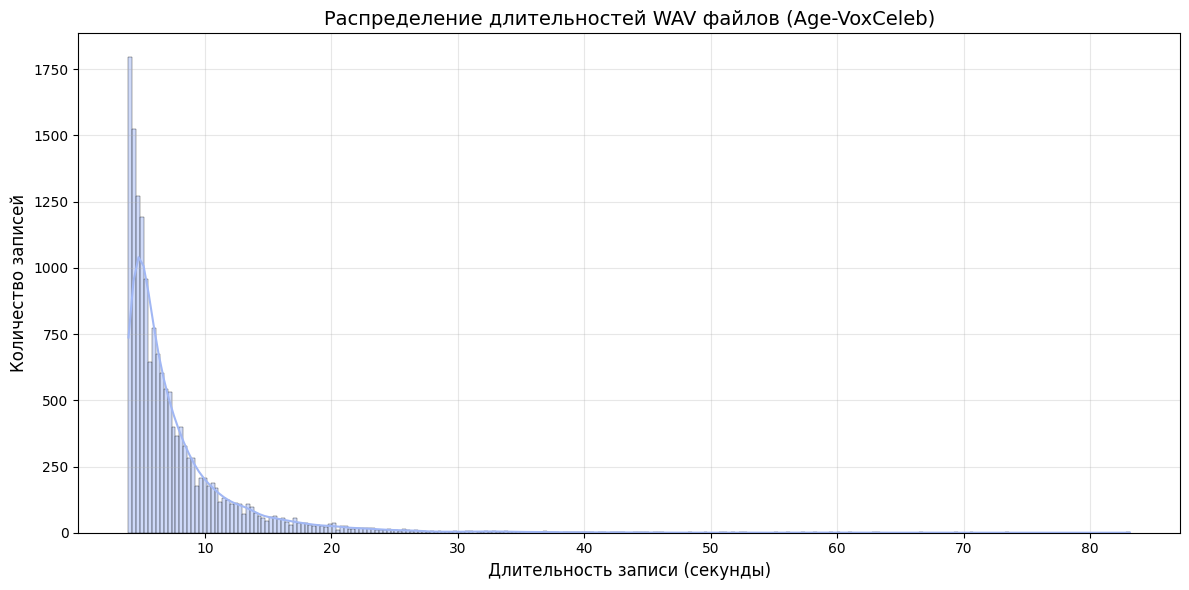


Статистика длительностей (по 16050 WAV файлам):
Минимальная длительность: 3.97 сек
Максимальная длительность: 83.14 сек
Средняя длительность: 7.74 сек
Медианная длительность: 6.02 сек
Стандартное отклонение: 5.16 сек


In [ ]:
def find_wav_files(base_path, utterance_ids, max_files=None): 
    """
    Находит WAV файлы по utterance_id
    """
    audio_files = []
    durations = []
    
    print("Поиск WAV файлов...")
    
    # Обрабатываем все файлы если max_files=None
    if max_files is None:
        max_files = len(utterance_ids)
    
    for i, utt_id in enumerate(utterance_ids[:max_files]):  # Без изменений
        wav_path = os.path.join(base_path, f"{utt_id}.wav")
        
        if os.path.exists(wav_path):
            try:
                duration = librosa.get_duration(path=wav_path)
                audio_files.append(wav_path)
                durations.append(duration)
                
                if len(audio_files) % 1000 == 0:
                    print(f"Найдено {len(audio_files)} WAV файлов...")
                    
            except Exception as e:
                continue
        
        if len(audio_files) >= max_files:
            break
    
    return audio_files, durations

# Берем ВСЕ данные (без подмножества)
sample_ids = df_age['utterance_id'].tolist()  # Добавлено .tolist()

# Находим WAV файлы для всех данных
audio_files, durations = find_wav_files(voxceleb2_path, sample_ids)  # Без max_files

# Весь остальной код без изменений
if durations:
    # Строим гистограмму длительностей
    plt.figure(figsize=(12, 6))
    
    # Гистограмма с KDE
    sns.histplot(durations, kde=True, color='#A1B7F4')
    plt.xlabel('Длительность записи (секунды)', fontsize=12)
    plt.ylabel('Количество записей', fontsize=12)
    plt.title('Распределение длительностей WAV файлов (Age-VoxCeleb)', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Статистика длительностей
    print(f"\nСтатистика длительностей (по {len(durations)} WAV файлам):")
    print(f"Минимальная длительность: {min(durations):.2f} сек")
    print(f"Максимальная длительность: {max(durations):.2f} сек")
    print(f"Средняя длительность: {np.mean(durations):.2f} сек")
    print(f"Медианная длительность: {np.median(durations):.2f} сек")
    print(f"Стандартное отклонение: {np.std(durations):.2f} сек")
else:
    print(f"WAV файлы не найдены. Проверьте путь: {voxceleb2_path}")

### Выводы
#### При проведении первичного анализа набора данных AgeVoxCeleb были выявлены следующие закономерности:
- Возрастной диапазон колеблется от 5 до 80 лет;
- Набор не размечен по возрастному критерию;
- При анализе распределения длительностей аудиозаписей выявлено, что средняя продолжительность составляет 7.32 секунды, а сами длительности колеблются от 3 до 83 секунд.